<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-2/blob/main/%5BMALU_RESPOSTAS%5D_Challenge_Frequ%C3%AAncia_e_Medidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO - O CATÁLOGO DA NETLIX

Arquivo .csv dos dados:

[netflix_titles_nov_2019.csv](https://drive.google.com/file/d/1cInLNo7aacuM80IA5iY84YGz40kmJc5d/view?usp=drive_link)

Pasta com os arquivos do desafio:

[Desafio - Challenge Frequência e Medidas](https://drive.google.com/drive/folders/1Mx-A-VAZ-Dv36H_f5z0ZcL02HfkhM6Xl?usp=sharing)


Variáveis:
* show_id - id único do filme/série.
* title - título do filme ou série
* director - diretor do filme ou série
* cast - elenco do filme ou série
* country - país do filme ou série
* date_added - data que foi adicionado no Netflix
* reading score - ano de lançamento original do filme
* rating - classificação da televisão
* duration - duração total do filme ou série.
* listed_in - categoria ou gênero do filme ou série.
* description -descrição do filme ou série.
* type - tipo de filme ou série


# 0. Preparação de ambiente

In [ ]:
# bibliotecas de base
import pandas as pd
import numpy as np

# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt

# biblioteca para estatística
import scipy.stats as stat

In [ ]:
url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/challenge-frequencia-medidas/refs/heads/main/netflix_titles_nov_2019.csv'
df = pd.read_csv(url)

In [ ]:
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [ ]:
df = df.rename(columns={'show_id': 'id',
                        'title': 'titulo',
                        'director':'diretor',
                        'cast': 'elenco',
                        'country': 'pais',
                        'date_added':'data_adicao',
                        'release_year':'data_lancamento',
                        'rating':'classificacao_tv',
                        'duration':'duracao',
                        'listed_in':'categoria_genero',
                        'description':'descricao',
                        'type':'tipo'})

df.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao_tv,duracao,categoria_genero,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


# 1.  Exploração inicial:

* Quantas linhas e colunas tem o dataset?

In [ ]:
# linhas e colunas
linhas, colunas = df.shape

print(f'linhas: {linhas}, colunas: {colunas}')

linhas: 5837, colunas: 12


* Quais são os tipos das variáveis e se há valores ausentes?

In [ ]:
df.info()

# dados object - dados do tipo strings
# dados int64 - dados do tipo inteiro

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                5837 non-null   int64 
 1   titulo            5837 non-null   object
 2   diretor           3936 non-null   object
 3   elenco            5281 non-null   object
 4   pais              5410 non-null   object
 5   data_adicao       5195 non-null   object
 6   data_lancamento   5837 non-null   int64 
 7   classificacao_tv  5827 non-null   object
 8   duracao           5837 non-null   object
 9   categoria_genero  5837 non-null   object
 10  descricao         5837 non-null   object
 11  tipo              5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [ ]:
# conta os valores faltantes, gera uma Series.Pandas
faltantes = df.isna().sum()

# transforma series em DataFrame e já renomeia a coluna de valores
faltantes = faltantes.to_frame(name='Valores nulos nas colunas')

faltantes

,Valores nulos nas colunas
id,0
titulo,0
diretor,1901
elenco,556
pais,427
data_adicao,642
data_lancamento,0
classificacao_tv,10
duracao,0
categoria_genero,0


# 2. Análises de frequência:

* Qual a proporção de filmes vs. séries no catálogo?



In [ ]:
df_proporcao = df.copy()
quantidade = df_proporcao['tipo'].value_counts()

# normalize=True -> ransforma a contagem bruta de dados em frequências relativas
# divide a quantidade de registros do tipo filme ou série pela quantidade de registros totais do dataframe. * por 100 para a porcentagem
proporcao = (df_proporcao['tipo'].value_counts(normalize=True) * 100).round(2)

df_proporcao_filmes_series = pd.DataFrame({
    'Quantidade': quantidade,
    'Porcentagem (%)': proporcao
})

df_proporcao_filmes_series

,Quantidade,Porcentagem (%)
tipo,,
Movie,3939,67.48
TV Show,1898,32.52


<Axes: title={'center': 'Proporção de Filmes vs. Séries no Catálogo'}, ylabel='Porcentagem (%)'>

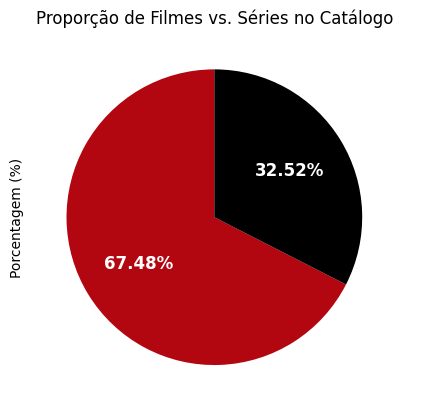

In [ ]:
df_proporcao_filmes_series['Porcentagem (%)'].plot(
    # tipo do gráfico - pizza
    kind='pie',

    # rótulo de dado '%(inicio da formatação) .2(quantidade de casas decimais) f(float) %%(para adicionar o simbolo e finalizar a formatação)
    autopct='%.2f%%',

    # ângulo de corte da pizza
    startangle=90,

    # cores do gráfico
    colors=['#B20710', '#000000'],

    # título do gráfico
    title='Proporção de Filmes vs. Séries no Catálogo',

    # formatação do textp
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 12}
)

* Qual o gênero mais frequente?

.explode(). pega uma linha que tem vários países e a "duplica", criando uma linha para cada país.

**Como funciona na prática?**  
Podemos ter:   
```Matrix | EUA, Austrália```

O .explode() transforma em duas linhas:  
```Matrix | EUA```   
```Matrix | Austrália```

In [ ]:
# por que não usamos o mode?
'''
Na coluna 'categoria_genero', em cada gênero, tinhamos registros com mais de um gênero registrado.
Foi necessário separar esses gêneros e a partir disso fazer a contagem deles.
'''
df_generos = df.copy()

# separa os por vírgula e cria lista de generos em cada registro
generos_categorias = df_generos['categoria_genero'].str.split(',')

# separa cada gênero em cada linha e retirando espaços dos gêneros para a contagem ser realizada
generos_categorias_separados = generos_categorias.explode().str.strip()

# faz a contagem dos generos e cria o dataframe
df_categorias_generos = generos_categorias_separados.value_counts().reset_index()

# removendo gênero 'internacional'
international = ['International Movies', 'International TV Shows']
df_categorias_generos = df_categorias_generos[~df_categorias_generos['categoria_genero'].isin(international)]

# renomeia as colunas dataframe
df_categorias_generos.columns = ['Gênero/categoria', 'Quantidade']

df_categorias_generos.head(5)

,Gênero/categoria,Quantidade
1,Dramas,1488
2,Comedies,992
4,Documentaries,658
5,TV Dramas,574
6,Action & Adventure,532


# 3.  Análises estatísticas:

* Qual a média, mediana e moda do tempo de duração dos
filmes?


In [ ]:
df_filmes = df[df['tipo'] == 'Movie'].copy()
df_filmes['duracao_num'] = df_filmes['duracao'].str.replace(' min', '').astype(int)
df_filmes.head(2)

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao_tv,duracao,categoria_genero,descricao,tipo,duracao_num
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,67
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,135


In [ ]:
print(f'a média da duração dos filmes é {df_filmes['duracao_num'].mean().round(2)}')
print(f'a mediana da duração dos filmes é {df_filmes['duracao_num'].median()}')
print(f'a moda (valor de duração que mais se repete) dos filmes é {df_filmes['duracao_num'].mode()}')

a média da duração dos filmes é 98.03
a mediana da duração dos filmes é 97.0
a moda (valor de duração que mais se repete) dos filmes é 0    90
Name: duracao_num, dtype: int64


* Qual o filme mais curto e mais longo?

In [ ]:
# procura na coluna de minutos o maior valor e pega o index desse valor
indice_maior_filme = df_filmes['duracao_num'].idxmax()

# com o .loc e o index do valor, pegamos o titulo do filme
filme_mais_longo = df_filmes.loc[indice_maior_filme, 'titulo']

# com o .loc e o index do valor, pegamos a duração em minutos
duracao_maxima = df_filmes.loc[indice_maior_filme, 'duracao_num']

print(f'O filme mais longo é {filme_mais_longo}, com {duracao_maxima} minutos.')

O filme mais longo é Black Mirror: Bandersnatch, com 312 minutos.


In [ ]:
# procura na coluna de minutos o menor valor e pega o index desse valor
indice_menor_filme = df_filmes['duracao_num'].idxmin()

# com o .loc e o index do valor, pegamos o titulo do filme
filme_mais_curto = df_filmes.loc[indice_menor_filme, 'titulo']

# com o .loc e o index do valor, pegamos a duração em minutos
duracao_minima = df_filmes.loc[indice_menor_filme, 'duracao_num']

print(f'O filme mais curto é {filme_mais_curto}, com {duracao_minima} minutos.')

O filme mais curto é Silent, com 3 minutos.


# 4. Visualização de dados:


* Criar um gráfico de barras para mostrar a quantidade de títulos
por gênero.


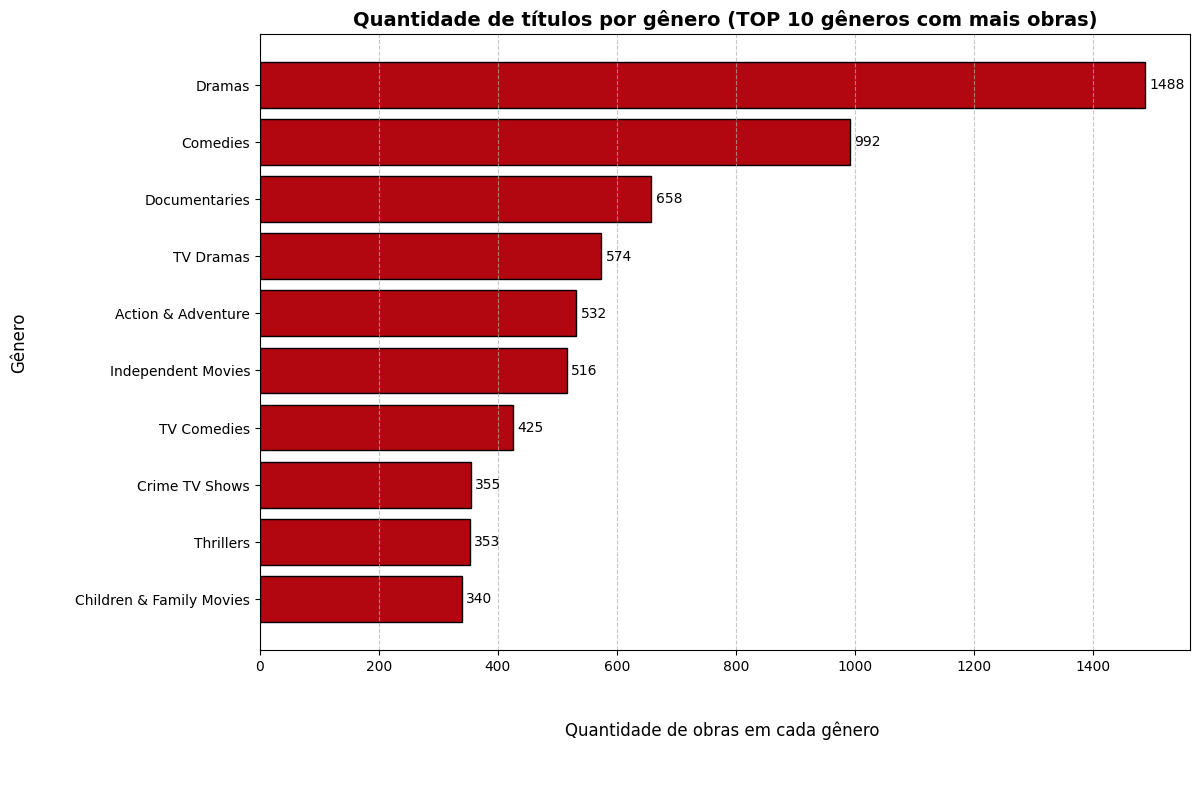

'\nexplode() pega uma linha que tem vários generos e a "duplica", criando uma linha para cada genero.\n\nComo funciona na prática?\nPodemos ter:\nMatrix | [\'Ação\', \'Ficção Científica\']\n\nO .explode() transforma em duas linhas:\nMatrix | Ação\nMatrix | Ficção Científica\n'

In [ ]:
df_obras_genero = df.copy()

# armazenando em uma variável toda a coluna de gênero.
# Cada linha terá uma lista de gênero de filmes, ex: [Drama, Ficção Científica, Romance]
obras_genero_unico = df_obras_genero['categoria_genero'].str.split(',')

# usando método explode para separar os itens da lista e deixar cada gênero em uma linha
obras_genero_explode = obras_genero_unico.explode()

# removendo espaços antes e depois de cada gênero
obras_genero_explode = obras_genero_explode.str.strip()

# contando as ocorrências de cada gênero
df_obras_genero = obras_genero_explode.value_counts().reset_index() # criando dataframe

# removendo gênero 'internacional'
international = ['International Movies', 'International TV Shows']
df_obras_genero = df_obras_genero[~df_obras_genero['categoria_genero'].isin(international)]

# renomeando colunas do dataframe
df_obras_genero.columns = ['genero', 'ocorrencias']

# aqui, salvo em uma variável os 10 primeiros generos do dataframe
contagem_generos_explode = df_obras_genero.head(10)

# criando variável com a sequência do maior para o menor
ordem_barras = contagem_generos_explode.iloc[::-1]

# criando gráfico
plt.figure(figsize=(12,8))  # comprimento e largura do gráfico
grafico = plt.barh(ordem_barras['genero'], ordem_barras['ocorrencias'], color='#B20710', edgecolor='black') # criando gráfico
plt.bar_label(grafico, padding=3) # adicionando rótulos em cima das barras

# personalizando o gráfico
plt.title('Quantidade de títulos por gênero (TOP 10 gêneros com mais obras)', fontsize=14, fontweight='bold') # título do gráfico
plt.xlabel('\n\nQuantidade de obras em cada gênero \n\n', fontsize=12) # título do eixo x
plt.ylabel('Gênero\n\n', fontsize=12) # título do eixo y
plt.grid(axis='x', linestyle='--', alpha=0.7)  # adiciona linhas de grade verticais

plt.show()

'''
explode() pega uma linha que tem vários generos e a "duplica", criando uma linha para cada genero.

Como funciona na prática?
Podemos ter:
Matrix | ['Ação', 'Ficção Científica']

O .explode() transforma em duas linhas:
Matrix | Ação
Matrix | Ficção Científica
'''

* Gêneros mais frequentes em filmes

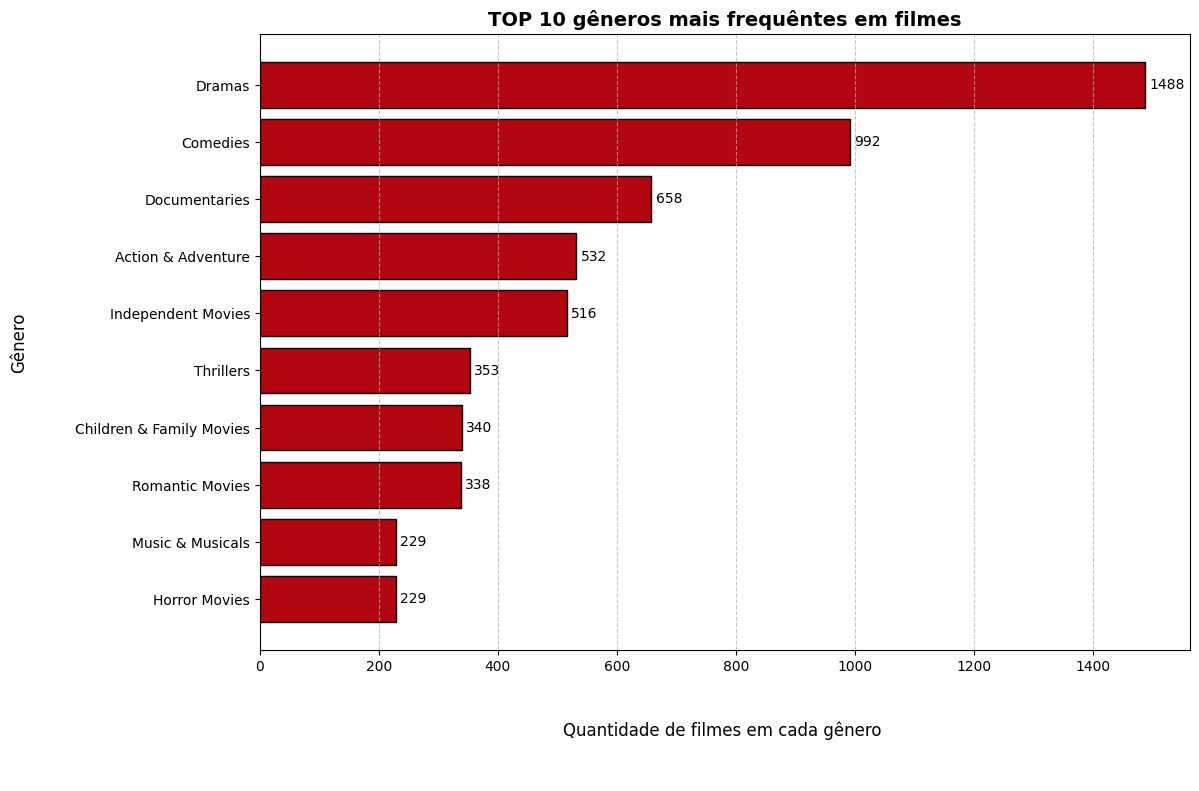

In [ ]:
# podemos separar os gêneros de filmes e séries
df_filmes_genero = df[df['tipo'] == 'Movie'].copy()

generos_lista = df['categoria_genero'].str.split(',')
generos_lista_explode = generos_lista.explode().str.strip()

df_genero_filmes = generos_lista_explode.value_counts().reset_index()

# existem gêneros que não são de filmes
lista_termos_remove = ['TV', 'International', 'Shows', 'Series', 'Docuseries', 'Stand-Up']

# junta os termos em uma única expressão regular: 'TV|Shows|Series|Docuseries'
# assim, a lista vira uma expressão só com o divisor |. O pandas procura se aquele registro de gênero tem TV ou International ou Shows e assim por diante
expressao_busca = '|'.join(lista_termos_remove)

# df_obras_genero = df_obras_genero[~df_obras_genero['categoria_genero'].isin(international)]
df_genero_filmes = df_genero_filmes[~df_genero_filmes['categoria_genero'].str.contains(expressao_busca, case = False)]

df_genero_filmes.columns =['genero', 'contagem']

# pegando os 10 primeiros
top_10 = df_genero_filmes.head(10)
top_10 = top_10.iloc[::-1]

# criando gráfico
plt.figure(figsize=(12,8))  # comprimento e largura do gráfico
grafico_filmes = plt.barh(top_10['genero'], top_10['contagem'], color='#B20710', edgecolor='black') # criando gráfico
plt.bar_label(grafico_filmes, padding=3) # rótulos em cima das barras

# personalizando o gráfico
plt.title('TOP 10 gêneros mais frequêntes em filmes', fontsize=14, fontweight='bold') # título do gráfico
plt.xlabel('\n\nQuantidade de filmes em cada gênero \n\n', fontsize=12) # título do eixo x
plt.ylabel('Gênero\n\n', fontsize=12) # título do eixo y
plt.grid(axis='x', linestyle='--', alpha=0.7)  # adiciona linhas de grade verticais

plt.show()


* Criar um histograma para analisar a distribuição da duração dos
filmes.

In [ ]:
df_filmes.head(2)

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao_tv,duracao,categoria_genero,descricao,tipo,duracao_num
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,67
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,135


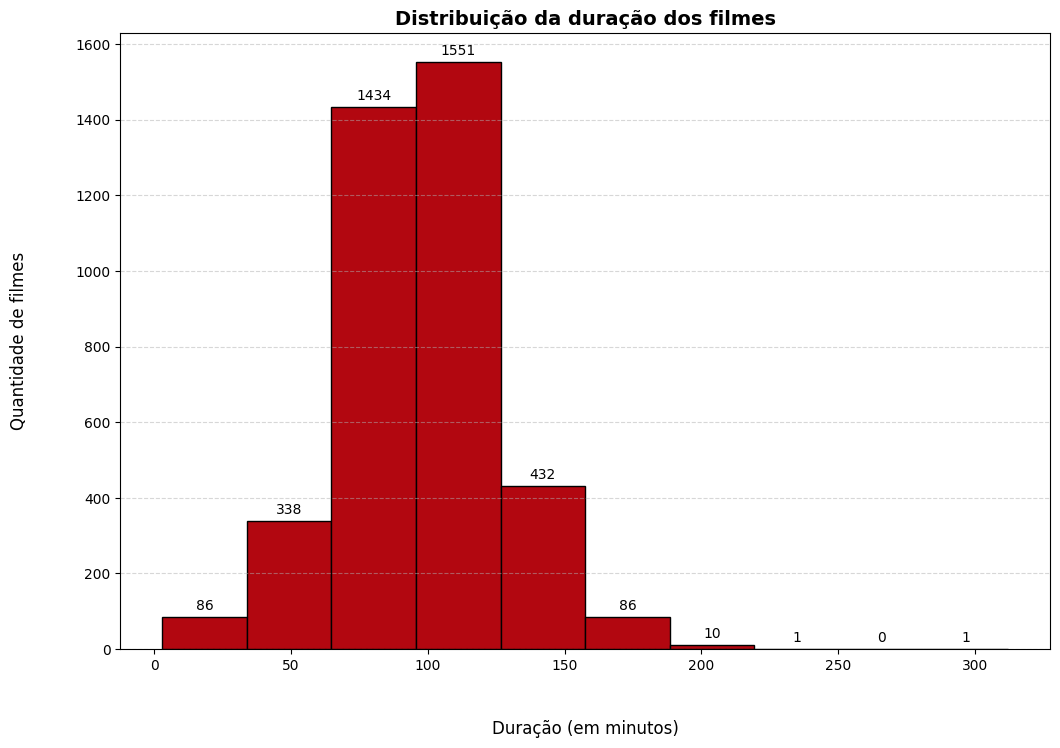

'\nO plt.hist() retorna uma tupla com 3 itens:\n\nOs valores de cada barra (contagens): Um array com o número de elementos que caíram dentro de cada intervalo (bin).\nAs divisões dos intervalos (bins): Um array com as coordenadas de onde cada barra começa e termina no eixo X.\nOs objetos visuais das barras (patches): Uma lista de objetos geométricos (retângulos) que o Matplotlib desenha na tela. Ou seja, as barras.\n'

In [ ]:
# dimensões do histograma
plt.figure(figsize=(12,8))

# O parâmetro 'bins' define em quantas "barras/faixas" os dados serão divididos
# para conseguirmos colocar os rótulos em cada barra, usamos _, _, para a variável armazenar o terceiro retorno do plt.hist (ou seja, as barras)
_, _, histograma = plt.hist(df_filmes['duracao_num'], bins=10, color='#B20710', edgecolor='black')

plt.title('Distribuição da duração dos filmes', fontsize=14, fontweight='bold') # título do gráfico
plt.xlabel('\n\nDuração (em minutos)', fontsize=12) # título eixo x
plt.ylabel('Quantidade de filmes\n\n', fontsize=12) # títiulo eixo y
plt.grid(axis='y', linestyle='--', alpha=0.5) # linhas de grade

plt.bar_label(histograma, padding=3) # adicionando rótulos em cima das barras

plt.show() # mostra o histograma


'''
O plt.hist() retorna uma tupla com 3 itens:

Os valores de cada barra (contagens): Um array com o número de elementos que caíram dentro de cada intervalo (bin).
As divisões dos intervalos (bins): Um array com as coordenadas de onde cada barra começa e termina no eixo X.
Os objetos visuais das barras (patches): Uma lista de objetos geométricos (retângulos) que o Matplotlib desenha na tela. Ou seja, as barras.
'''


# Atividade extra:

* Quais são os 5 países que possuem mais produções no catálogo?

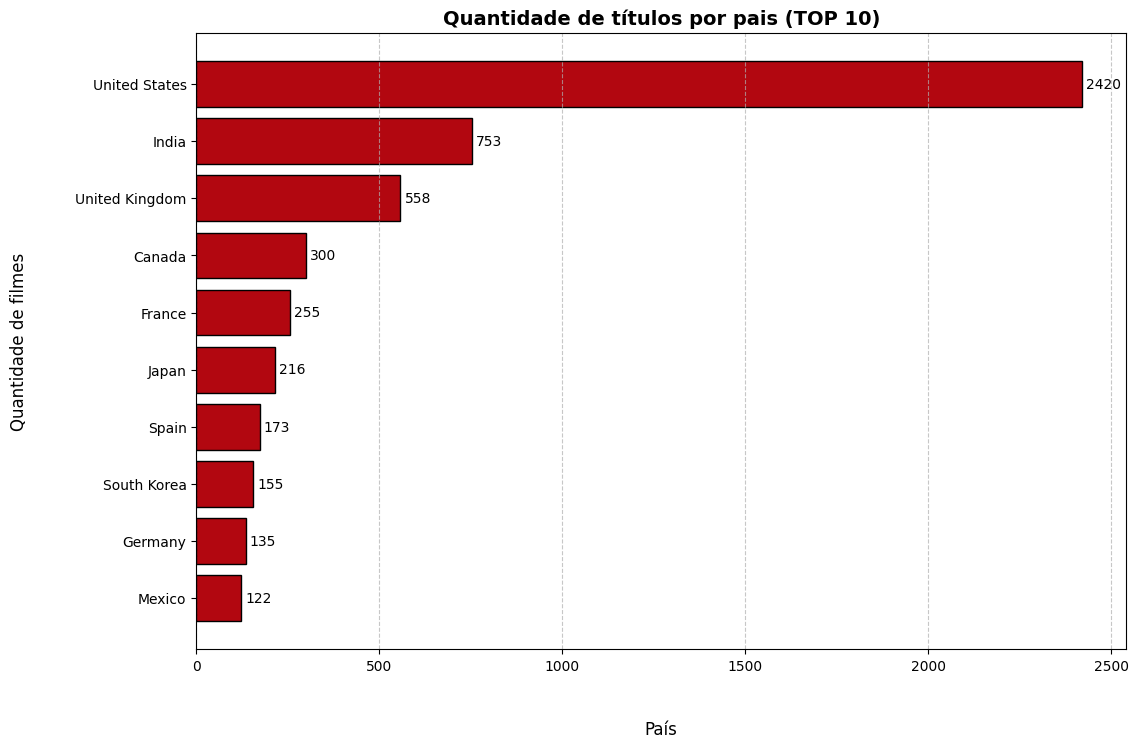

In [ ]:
'''
usamos o explode() pois, tem filmes/séries que possuem mais de um pais.
'''

df_paises = df.copy()
paises = df_paises['pais'].str.split(', ')
paises_separados = paises.explode().str.strip()

df_paises_contagem = paises_separados.value_counts().reset_index().head(10)
df_paises_contagem.columns = ['Pais', 'QTDE de obras que o pais possui']

ordem_barras_paises = df_paises_contagem.iloc[::-1]

plt.figure(figsize=(12,8))
paises = plt.barh(ordem_barras_paises['Pais'], ordem_barras_paises['QTDE de obras que o pais possui'], color='#B20710', edgecolor='black')

plt.title('Quantidade de títulos por pais (TOP 10)', fontsize=14, fontweight='bold')
plt.xlabel('\n\nPaís', fontsize=12)
plt.ylabel('Quantidade de filmes\n\n', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.bar_label(paises, padding=3)

plt.show()



*   [PROPOSTA] Quantos títulos foram lançados por ano (olhe o ano original de lançamento do filme)? Faça o gráfico com o TOP 5 anos com mais lançamentos.


In [ ]:
df.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao_tv,duracao,categoria_genero,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


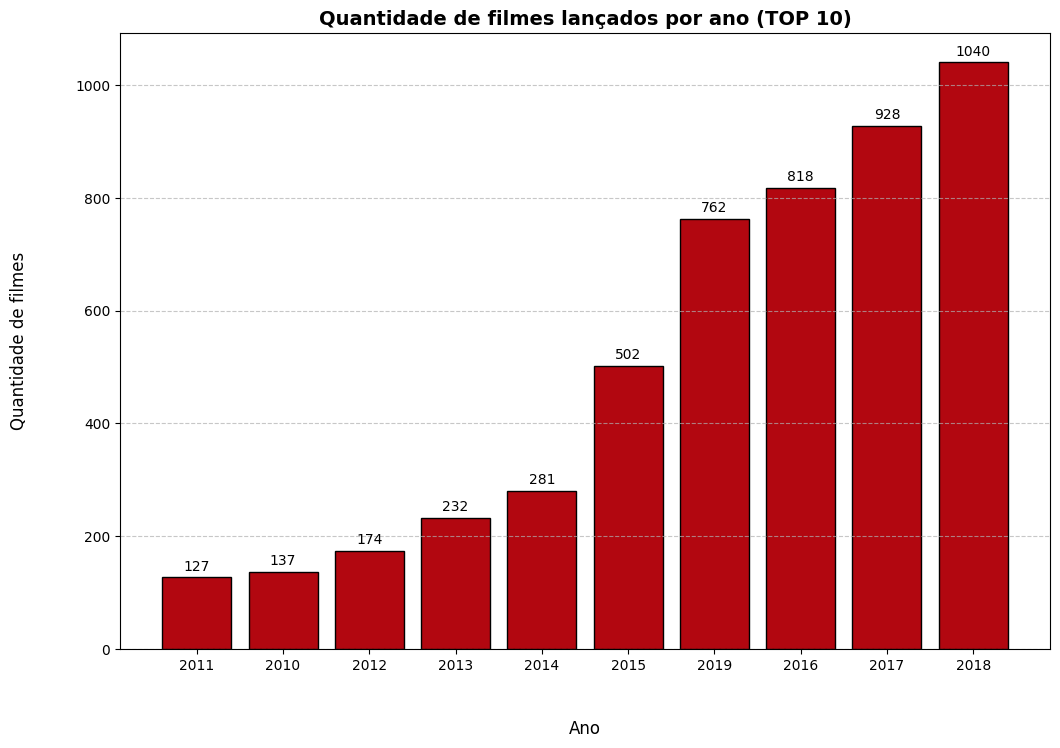

In [ ]:
df_filmes_por_ano = df.copy()

filmes_ano = df_filmes_por_ano['data_lancamento']
df_filmes_ano = filmes_ano.value_counts().reset_index().head(10)
df_filmes_ano.columns = ['data_lancamento', 'filmes_lancados']

df_filmes_ano = df_filmes_ano.sort_values(by='filmes_lancados', ascending=True)

df_filmes_ano['data_lancamento'] = df_filmes_ano['data_lancamento'].astype(str)


plt.figure(figsize=(12,8))
grafico = plt.bar(df_filmes_ano['data_lancamento'], df_filmes_ano['filmes_lancados'], color='#B20710', edgecolor='black')

plt.title('Quantidade de filmes lançados por ano (TOP 10)', fontsize=14, fontweight='bold')
plt.xlabel('\n\nAno', fontsize=12)
plt.ylabel('Quantidade de filmes\n\n', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#plt.xticks(df_filmes_ano['data_lancamento'])
plt.bar_label(grafico, padding=3, fontsize=10)
#plt.ylim(0, 1150)

plt.show()



* Qual é a quantidade de filmes e séries por países?

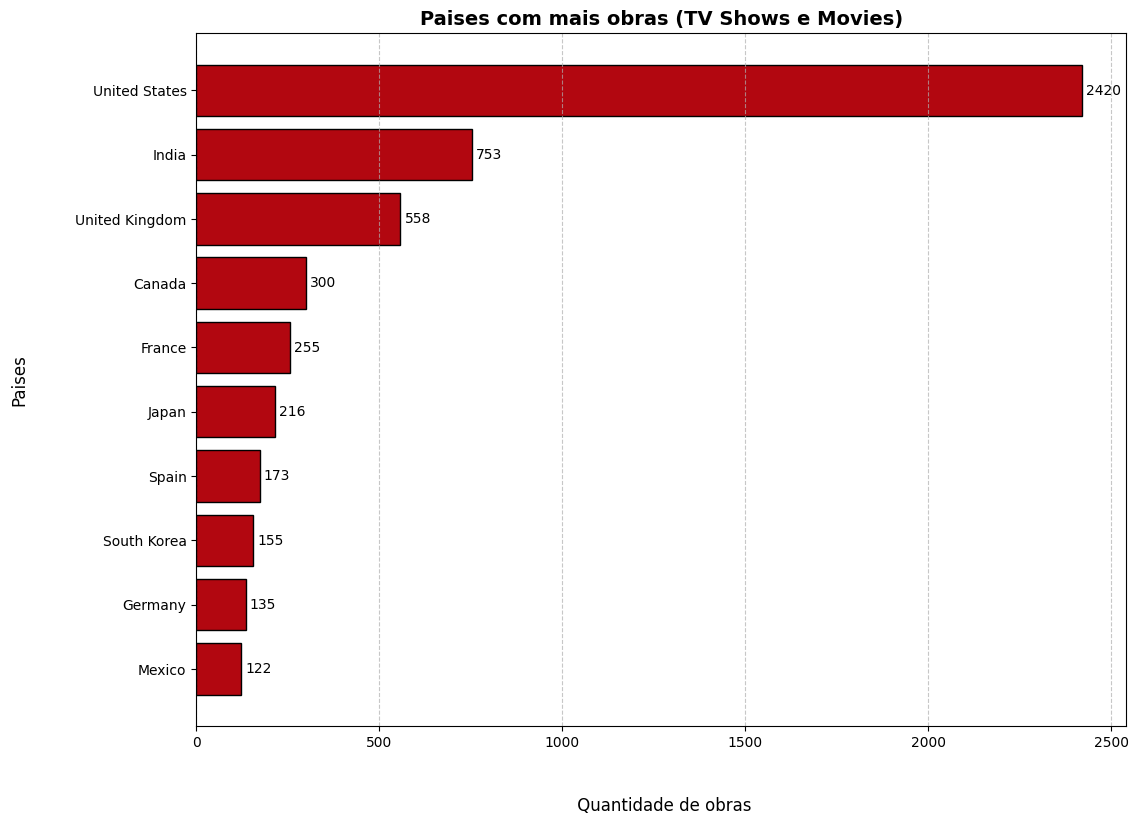

In [ ]:
df_obras_qtde_paises = df.copy()

df_obras_qtde_paises = df_obras_qtde_paises.dropna(subset=['pais'])

df_obras_qtde_paises['pais'] = df_obras_qtde_paises['pais'].str.split(', ')

df_paises_separados = df_obras_qtde_paises.explode('pais')

df_contagem_filmes_paises = df_paises_separados.groupby(['pais']).size().reset_index(name='quantidade de obras')

df_contagem_filmes_paises = df_contagem_filmes_paises.sort_values(by='quantidade de obras', ascending=False) # pegamos os valores do maior para o menor

paises_com_mais_obras = df_contagem_filmes_paises.head(10)

paises_com_mais_obras = paises_com_mais_obras.sort_values(by='quantidade de obras', ascending=True) # reordenando do menor para o maior, pois, o gráfico vertical começa de baixo pra cima
                                                                                                    # ou seja, quando começamos com asceding=False, pegamos o menor para o maior
                                                                                                    # com o asceding=True, pegamos o maior para o menor

plt.figure(figsize=(12,9))
grafico = plt.barh(paises_com_mais_obras['pais'], paises_com_mais_obras['quantidade de obras'], color='#B20710', edgecolor='black')

plt.title('Paises com mais obras (TV Shows e Movies)', fontsize=14, fontweight='bold')
plt.xlabel('\n\n Quantidade de obras', fontsize=12)
plt.ylabel('Paises\n\n', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.bar_label(grafico, padding=3, fontsize=10)

plt.show()